In [ ]:
import random
import networkx as nx 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import EoN
from tqdm import trange
import pandas as pd
import random
from sklearn.model_selection import train_test_split



NameError: name 'G' is not defined

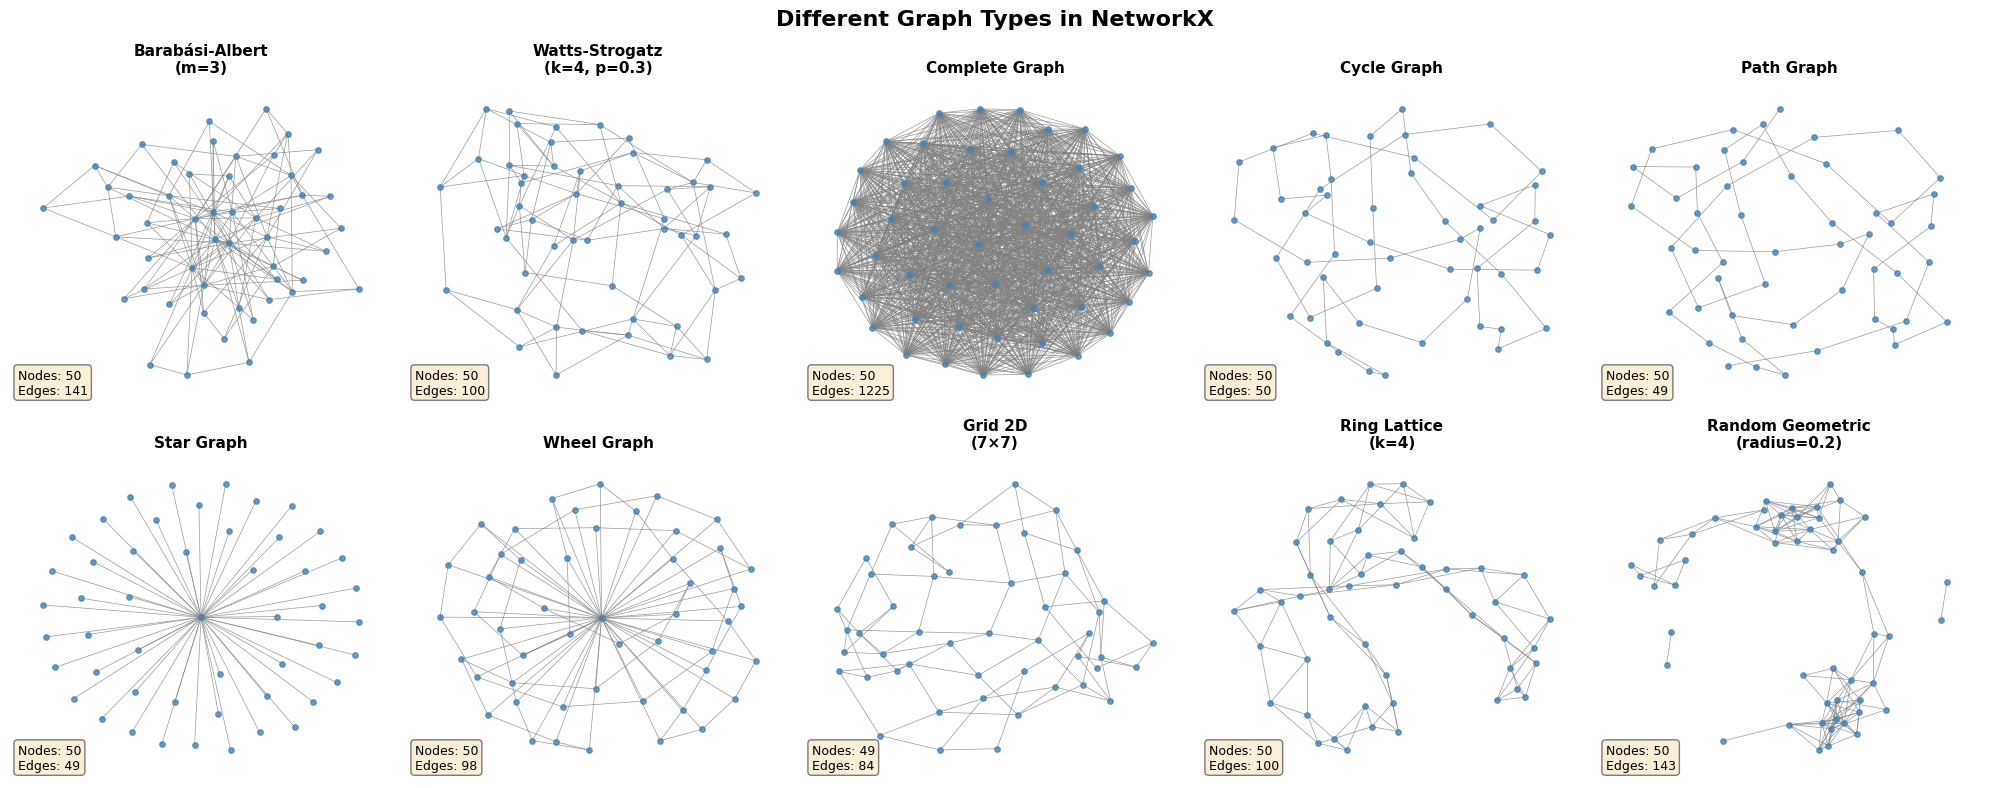

In [2]:
# Visualization of different graph types in NetworkX
import networkx as nx
import matplotlib.pyplot as plt

N = 50
seed_layout = 42

# Define different graph types
graphs = {
    'Barabási-Albert\n(m=3)': nx.barabasi_albert_graph(N, 3, seed=seed_layout),
    'Watts-Strogatz\n(k=4, p=0.3)': nx.watts_strogatz_graph(N, 4, 0.3, seed=seed_layout),
    'Complete Graph': nx.complete_graph(N),
    'Cycle Graph': nx.cycle_graph(N),
    'Path Graph': nx.path_graph(N),
    'Star Graph': nx.star_graph(N-1),
    'Wheel Graph': nx.wheel_graph(N),
    'Grid 2D\n(7×7)': nx.grid_2d_graph(7, 7),
    'Ring Lattice\n(k=4)': nx.circulant_graph(N, [1, 2]),
    'Random Geometric\n(radius=0.2)': nx.random_geometric_graph(N, 0.2, seed=seed_layout),
}

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, (title, G) in zip(axes, graphs.items()):
    if isinstance(G, nx.MultiGraph) or isinstance(G, nx.MultiDiGraph):
        G = nx.Graph(G)
    
    # Use different layout algorithms for better visualization
    if 'Grid' in title or 'Lattice' in title:
        pos = nx.spring_layout(G, seed=seed_layout, k=0.5, iterations=50)
    else:
        pos = nx.spring_layout(G, seed=seed_layout, k=0.5, iterations=50)
    
    # Draw
    nx.draw(
        G, pos, ax=ax,
        with_labels=False,
        node_color='steelblue',
        edge_color='gray',
        node_size=15 if G.number_of_nodes() > 30 else 30,
        width=0.5,
        alpha=0.8
    )
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # Add info
    info_text = f"Nodes: {G.number_of_nodes()}\nEdges: {G.number_of_edges()}"
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Different Graph Types in NetworkX', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


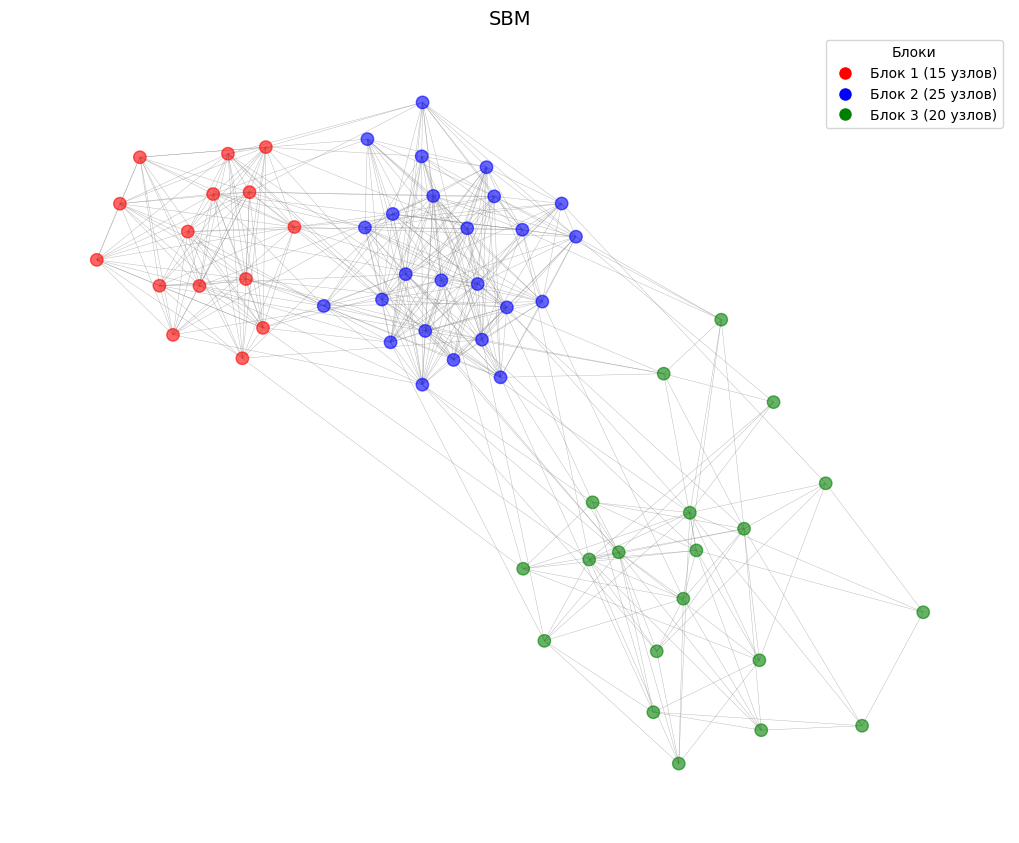

In [3]:
N = 60
sizes = [15, 25, 20]  # Размеры блоков (групп)
probs = np.array([
    [0.8, 0.1, 0.02],  # Матрица вероятностей соединений между блоками
    [0.1, 0.6, 0.05],
    [0.02, 0.05, 0.4]
])
G = nx.stochastic_block_model(sizes, probs)

colors = ['red', 'blue', 'green']
node_colors = []
for i, size in enumerate(sizes):
    node_colors.extend([colors[i]] * size)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.3)
nx.draw(G, pos,
        node_color=node_colors,
        with_labels=False,
        node_size=80,
        edge_color='gray',
        alpha=0.6,
        width=0.3)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors[i], markersize=10,
                              label=f'Блок {i+1} ({sizes[i]} узлов)')
                  for i in range(len(sizes))]
plt.legend(handles=legend_elements, title='Блоки', loc='upper right')

plt.title('SBM', fontsize=14)
plt.axis('off')
plt.show()

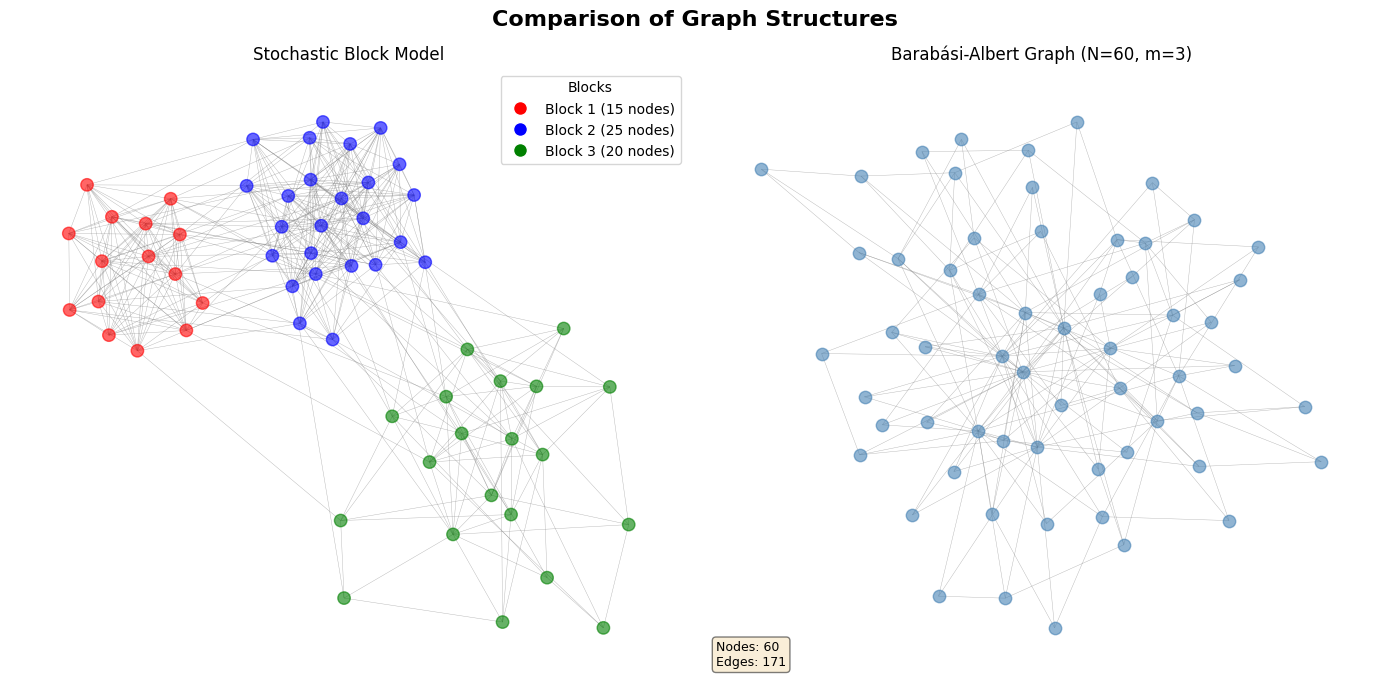

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Stochastic Block Model
N = 60
sizes = [15, 25, 20]  # Block sizes (groups)
probs = np.array([
    [0.8, 0.1, 0.02],  # Probability matrix for connections between blocks
    [0.1, 0.6, 0.05],
    [0.02, 0.05, 0.4]
])
G_sbm = nx.stochastic_block_model(sizes, probs)

# Barabási-Albert Graph
G_ba = nx.barabasi_albert_graph(60, 3, seed=42)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# SBM plot
colors = ['red', 'blue', 'green']
node_colors = []
for i, size in enumerate(sizes):
    node_colors.extend([colors[i]] * size)

pos_sbm = nx.spring_layout(G_sbm, seed=42, k=0.3)
nx.draw(G_sbm, pos_sbm, ax=axes[0],
        node_color=node_colors,
        with_labels=False,
        node_size=80,
        edge_color='gray',
        alpha=0.6,
        width=0.3)
axes[0].set_title('Stochastic Block Model')
axes[0].axis('off')

legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=colors[i], markersize=10,
                              label=f'Block {i+1} ({sizes[i]} nodes)')
                  for i in range(len(sizes))]
axes[0].legend(handles=legend_elements, title='Blocks', loc='upper right')

# BA plot
pos_ba = nx.spring_layout(G_ba, seed=42, k=0.3)
nx.draw(G_ba, pos_ba, ax=axes[1],
        node_color='steelblue',
        with_labels=False,
        node_size=80,
        edge_color='gray',
        alpha=0.6,
        width=0.3)
axes[1].set_title('Barabási-Albert Graph (N=60, m=3)')
axes[1].axis('off')

info_text = f"Nodes: {G_ba.number_of_nodes()}\nEdges: {G_ba.number_of_edges()}"
axes[1].text(0.02, 0.02, info_text, transform=axes[1].transAxes, fontsize=9,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Comparison of Graph Structures', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

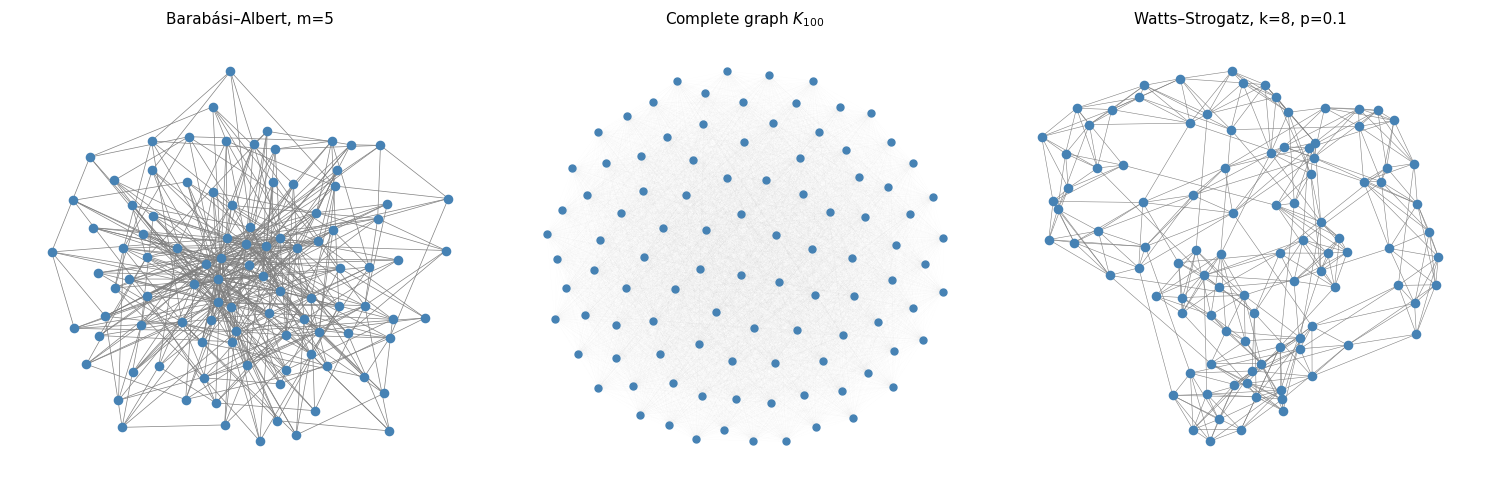

In [5]:
N_vis = 100
seed_layout = 42

G_ba = nx.barabasi_albert_graph(N_vis, 5, seed=seed_layout)
G_complete = nx.complete_graph(N_vis)
G_ws = nx.watts_strogatz_graph(N_vis, 8, 0.1, seed=seed_layout)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

graphs_titles = [
    (G_ba, "Barabási–Albert, m=5", dict(node_size=35, width=0.5)),
    (G_complete, "Complete graph $K_{100}$", dict(node_size=25, width=0.03, edge_color=(0.4, 0.4, 0.4, 0.12))),
    (G_ws, "Watts–Strogatz, k=8, p=0.1", dict(node_size=35, width=0.4)),
]

for ax, (G, title, draw_kw) in zip(axes, graphs_titles):
    pos = nx.spring_layout(G, seed=seed_layout, k=0.35)
    nx.draw(
        G, pos, ax=ax,
        with_labels=False,
        node_color="steelblue",
        edge_color=draw_kw.get("edge_color", "gray"),
        **{k: v for k, v in draw_kw.items() if k != "edge_color"},
    )
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()
